In [ ]:
# Load drive to access saved results
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

**Compute and Save Average Accuracy over Sessions and Positional Accuracy for all Seeded Runs**

In [ ]:
# Function for calculating within session accuracy
def compute_session_acc(session_df):

    # Filter out rows where skip_prediction is 'Invalid'
    valid_session_df = session_df[session_df['skip_prediction'] != 'Invalid']

    # Get true and predicted labels from the filtered dataframe
    if 'ground_truth' in valid_session_df.columns:
        true_labels = valid_session_df['ground_truth']
    else:
        true_labels = valid_session_df['skip_2']  # Use 'skip_2' for dummy classifier
    pred_labels = valid_session_df['skip_prediction']

    # Ensure that 'True'/'False' strings are converted to booleans
    pred_labels = pred_labels.apply(lambda x: True if x == 'True' else False if x == 'False' else x)

    accuracies = accuracy_score(true_labels, pred_labels, normalize=False)

    # Since accuracy_score returns the number of correct predictions, divide by T to get session accuracy - T includes invalid preds
    T = len(session_df)
    session_acc = accuracies / T
    return session_acc

In [ ]:
def compute_position_acc(responses_df):
    # Group by session position and calculate accuracy for each position
    grouped = responses_df.groupby('session_position')

    def process_position(df):
        # Filter out 'Invalid' predictions
        valid_df = df[df['skip_prediction'] != 'Invalid']

        # Get true and predicted labels from the filtered dataframe
        true_labels = valid_df['ground_truth'] if 'ground_truth' in valid_df.columns else valid_df['skip_2'] # Account for the dummy results
        pred_labels = valid_df['skip_prediction']

        # Ensure 'True'/'False' strings are converted to booleans
        pred_labels = pred_labels.apply(lambda x: True if x == 'True' else False if x == 'False' else x)

        # Compute accuracy for valid predictions only
        return accuracy_score(true_labels, pred_labels)

    # Apply the processing for each group (session position)
    position_accuracy = grouped.apply(process_position)

    # Convert the Series to a dictionary
    return position_accuracy.to_dict()

In [ ]:
def average_experiment_results(experiment, llm_name, seeds):
    all_session_acc = []
    all_position_acc = {}  # Initialize as a dictionary

    for seed in seeds:
        base_path = f'/content/drive/My Drive/ProjectResults2/{llm_name}/Seed_{seed}/{experiment}/'

        # Load the results
        results_df = pd.read_csv(os.path.join(base_path, f'{experiment}_results.csv'))

        # Compute session accuracy for each session
        session_ids = results_df['session_id'].unique()
        seed_session_acc = []

        for session_id in session_ids:
            session_df = results_df[results_df['session_id'] == session_id]
            acc = compute_session_acc(session_df)
            seed_session_acc.append(acc)

        # Store the average accuracy for this seed
        all_session_acc.append(sum(seed_session_acc) / len(seed_session_acc))

        # Compute positional accuracy
        position_acc = compute_position_acc(results_df)

        # Aggregate positional accuracies across seeds
        for pos, acc in position_acc.items():
            if pos not in all_position_acc:
                all_position_acc[pos] = []
            all_position_acc[pos].append(acc)

    # Average the session accuracies across seeds
    avg_session_acc_across_seeds = (sum(all_session_acc) / len(all_session_acc) * 100).round(2)

    # Average the position accuracies across seeds
    avg_position_acc = {}
    for pos, acc_list in all_position_acc.items():
        avg_position_acc[pos] = (sum(acc_list) / len(acc_list)) * 100  # Convert to percentage and average

    return avg_session_acc_across_seeds, avg_position_acc

In [ ]:
# Function for finding the average number of catastrophic failures for experiments over seeded runs
def average_catastrophic_failures(experiment, llm_name, seeds):
    all_failures = []

    for seed in seeds:
        base_path = f'/content/drive/My Drive/ProjectResults2/{llm_name}/Seed_{seed}/{experiment}/'

        # Load the results
        results_df = pd.read_csv(os.path.join(base_path, f'{experiment}_results.csv'))

        # Count the number of 'Invalid' results
        num_invalid = results_df[results_df['skip_prediction'] == 'Invalid'].shape[0]

        # Store the number of failures for this seed
        all_failures.append(num_invalid)

    # Average the failures across seeds
    avg_failures = sum(all_failures) / len(all_failures)
    return round(avg_failures, 2)

In [ ]:
# Dictionary for holding the results for llama 3.0 and 3.1
llama3_0_average_accuracies = {}
llama3_1_average_accuracies = {}
gemini_average_accuracies = {}
llama3_0_position_accuracies = {}
llama3_1_position_accuracies = {}
gemini_position_accuracies = {}
llama3_0_average_failures = {}
llama3_1_average_failures = {}
gemini_average_failures = {}

# Define the experiments and seeds
experiments = [
    'exp1_zero_shot', 'exp1_one_shot',
    'exp2_zero_shot', 'exp2_one_shot',
    'exp3_zero_shot', 'exp3_one_shot',
    'exp4_zero_shot', 'exp4_one_shot',
    'exp5_zero_shot', 'exp5_one_shot'
]
seeds = [1, 2, 3]

# Calculate and store average session and position-wise accuracies, and average catastrophic failures for llama 3.0
for experiment in experiments:
    avg_session_acc, avg_position_acc = average_experiment_results(experiment, 'llama3_0', seeds)
    llama3_0_average_accuracies[experiment] = avg_session_acc
    llama3_0_position_accuracies[experiment] = avg_position_acc
    llama3_0_failures_count = average_catastrophic_failures(experiment, 'llama3_0', seeds)
    llama3_0_average_failures[experiment] = llama3_0_failures_count

# Calculate and store average session and position-wise accuracies, and average catastrophic failures for llama 3.1
for experiment in experiments:
    avg_session_acc, avg_position_acc = average_experiment_results(experiment, 'llama3_1', seeds)
    llama3_1_average_accuracies[experiment] = avg_session_acc
    llama3_1_position_accuracies[experiment] = avg_position_acc
    llama3_1_failures_count = average_catastrophic_failures(experiment, 'llama3_1', seeds)
    llama3_1_average_failures[experiment] = llama3_1_failures_count

# Calculate and store average session and position-wise accuracies, and average catastrophic failures for gemini 1.5 flash
for experiment in experiments:
    avg_session_acc, avg_position_acc = average_experiment_results(experiment, 'gemini', seeds)
    gemini_average_accuracies[experiment] = avg_session_acc
    gemini_position_accuracies[experiment] = avg_position_acc
    gemini_failures_count = average_catastrophic_failures(experiment, 'gemini', seeds)
    gemini_average_failures[experiment] = gemini_failures_count

# Find dummy classifier average session and position-wise results
dummy_session_acc = compute_session_acc(pd.read_csv('/content/drive/My Drive/ProjectResults2/dummy/Seed_1/dummy_classifier/dummy_classifier_results.csv'))
dummy_position_acc = compute_position_acc(pd.read_csv('/content/drive/My Drive/ProjectResults2/dummy/Seed_1/dummy_classifier/dummy_classifier_results.csv'))

**Display Results**

In [ ]:
print(f'Dummy Classifier Accuracy: {dummy_session_acc*100:.2f}%')
print(f"Dummy Classifier Position Accuracy:")
for position, acc in dummy_position_acc.items():
    print(f"Position {position}: {acc*100:.2f}%")

Dummy Classifier Accuracy: 52.63%
Dummy Classifier Position Accuracy:
Position 2: 59.17%
Position 3: 53.25%
Position 4: 48.52%
Position 5: 50.30%
Position 6: 54.68%
Position 7: 50.46%
Position 8: 59.57%
Position 9: 47.67%
Position 10: 47.37%


In [ ]:
# Print Llama 3.0 results
for experiment, avg_acc in llama3_0_average_accuracies.items():
    print(f"{experiment}: {avg_acc}%")

for experiment, failures in llama3_0_average_failures.items():
    print(f"{experiment} Catastrophic Failures: {failures}")

print("\nLlama 3.0 Average Position Accuracy:")
for experiment, position_acc in llama3_0_position_accuracies.items():
    print(f"\n{experiment}:")
    for position, acc in position_acc.items():
        print(f"  Position {position}: {acc:.2f}%")

exp1_zero_shot: 57.06%
exp1_one_shot: 50.04%
exp2_zero_shot: 54.13%
exp2_one_shot: 55.13%
exp3_zero_shot: 53.29%
exp3_one_shot: 49.9%
exp4_zero_shot: 52.44%
exp4_one_shot: 52.1%
exp5_zero_shot: 52.08%
exp5_one_shot: 53.99%
exp1_zero_shot Catastrophic Failures: 0.0
exp1_one_shot Catastrophic Failures: 0.0
exp2_zero_shot Catastrophic Failures: 0.0
exp2_one_shot Catastrophic Failures: 0.0
exp3_zero_shot Catastrophic Failures: 0.0
exp3_one_shot Catastrophic Failures: 0.0
exp4_zero_shot Catastrophic Failures: 6.67
exp4_one_shot Catastrophic Failures: 0.0
exp5_zero_shot Catastrophic Failures: 4.0
exp5_one_shot Catastrophic Failures: 0.0

Llama 3.0 Average Position Accuracy:

exp1_zero_shot:
  Position 2: 57.20%
  Position 3: 54.44%
  Position 4: 58.19%
  Position 5: 59.76%
  Position 6: 57.31%
  Position 7: 53.52%
  Position 8: 58.16%
  Position 9: 49.61%
  Position 10: 64.47%

exp1_one_shot:
  Position 2: 39.64%
  Position 3: 46.75%
  Position 4: 53.25%
  Position 5: 52.86%
  Position 6: 54

In [ ]:
# Print Llama 3.1 results
for experiment, avg_acc in llama3_1_average_accuracies.items():
    print(f"{experiment}: {avg_acc}%")

for experiment, failures in llama3_1_average_failures.items():
    print(f"{experiment} Catastrophic Failures: {failures}")

print("\nLlama 3.1 Average Position Accuracy:")
for experiment, position_acc in llama3_1_position_accuracies.items():
    print(f"\n{experiment}:")
    for position, acc in position_acc.items():
        print(f"  Position {position}: {acc:.2f}%")

exp1_zero_shot: 52.37%
exp1_one_shot: 49.32%
exp2_zero_shot: 52.6%
exp2_one_shot: 56.17%
exp3_zero_shot: 52.07%
exp3_one_shot: 53.08%
exp4_zero_shot: 52.39%
exp4_one_shot: 55.57%
exp5_zero_shot: 52.23%
exp5_one_shot: 57.18%
exp1_zero_shot Catastrophic Failures: 0.0
exp1_one_shot Catastrophic Failures: 0.0
exp2_zero_shot Catastrophic Failures: 0.0
exp2_one_shot Catastrophic Failures: 0.0
exp3_zero_shot Catastrophic Failures: 1.33
exp3_one_shot Catastrophic Failures: 0.0
exp4_zero_shot Catastrophic Failures: 2.0
exp4_one_shot Catastrophic Failures: 0.0
exp5_zero_shot Catastrophic Failures: 0.67
exp5_one_shot Catastrophic Failures: 0.0

Llama 3.1 Average Position Accuracy:

exp1_zero_shot:
  Position 2: 58.78%
  Position 3: 52.86%
  Position 4: 52.07%
  Position 5: 51.48%
  Position 6: 47.00%
  Position 7: 48.62%
  Position 8: 42.91%
  Position 9: 55.81%
  Position 10: 57.02%

exp1_one_shot:
  Position 2: 48.92%
  Position 3: 48.32%
  Position 4: 48.32%
  Position 5: 49.31%
  Position 6: 

In [ ]:
# Print Gemini results
for experiment, avg_acc in gemini_average_accuracies.items():
    print(f"{experiment}: {avg_acc}%")

for experiment, failures in gemini_average_failures.items():
    print(f"{experiment} Catastrophic Failures: {failures}")

print("\nGemini Average Position Accuracy:")
for experiment, position_acc in gemini_position_accuracies.items():
    print(f"\n{experiment}:")
    for position, acc in position_acc.items():
        print(f"  Position {position}: {acc:.2f}%")

exp1_zero_shot: 68.35%
exp1_one_shot: 66.88%
exp2_zero_shot: 67.88%
exp2_one_shot: 65.37%
exp3_zero_shot: 66.03%
exp3_one_shot: 62.93%
exp4_zero_shot: 67.26%
exp4_one_shot: 61.98%
exp5_zero_shot: 66.22%
exp5_one_shot: 59.43%
exp1_zero_shot Catastrophic Failures: 0.0
exp1_one_shot Catastrophic Failures: 0.0
exp2_zero_shot Catastrophic Failures: 0.0
exp2_one_shot Catastrophic Failures: 0.0
exp3_zero_shot Catastrophic Failures: 0.0
exp3_one_shot Catastrophic Failures: 0.0
exp4_zero_shot Catastrophic Failures: 0.0
exp4_one_shot Catastrophic Failures: 0.0
exp5_zero_shot Catastrophic Failures: 0.0
exp5_one_shot Catastrophic Failures: 0.0

Gemini Average Position Accuracy:

exp1_zero_shot:
  Position 2: 63.71%
  Position 3: 69.23%
  Position 4: 74.75%
  Position 5: 70.41%
  Position 6: 68.59%
  Position 7: 61.77%
  Position 8: 71.28%
  Position 9: 58.53%
  Position 10: 66.23%

exp1_one_shot:
  Position 2: 63.91%
  Position 3: 69.23%
  Position 4: 74.16%
  Position 5: 68.24%
  Position 6: 67.6

**Convert to Dataframes and Save Results**

In [ ]:
dummy_session_acc = round(dummy_session_acc * 100, 2)

# Unify the session accuracy results
session_accuracy_results = {
    'Dummy Classifier': dummy_session_acc,
    'Llama 3.0': llama3_0_average_accuracies,
    'Llama 3.1': llama3_1_average_accuracies,
    'Gemini': gemini_average_accuracies
}

# Create a DataFrame from the session accuracy results
df_session_accuracy = pd.DataFrame(session_accuracy_results)
# Transpose the DataFrame to have LLMs as rows and experiments as columns
df_session_accuracy = df_session_accuracy.T

# Set the index name for clarity
df_session_accuracy.index.name = 'Model'
# Save dataframe
df_session_accuracy.to_csv('/content/drive/MyDrive/ProjectResults2/Tables/session_accuracy_results.csv')

In [ ]:
df_session_accuracy

,exp1_zero_shot,exp1_one_shot,exp2_zero_shot,exp2_one_shot,exp3_zero_shot,exp3_one_shot,exp4_zero_shot,exp4_one_shot,exp5_zero_shot,exp5_one_shot
Model,,,,,,,,,,
Dummy Classifier,52.63,52.63,52.63,52.63,52.63,52.63,52.63,52.63,52.63,52.63
Llama 3.0,57.06,50.04,54.13,55.13,53.29,49.90,52.44,52.10,52.08,53.99
Llama 3.1,52.37,49.32,52.60,56.17,52.07,53.08,52.39,55.57,52.23,57.18
Gemini,68.35,66.88,67.88,65.37,66.03,62.93,67.26,61.98,66.22,59.43


In [ ]:
# Convert dummy accuracies to percentages
dummy_position_acc = {position: round(acc * 100, 2) for position, acc in dummy_position_acc.items()}

# Unify the positional accuracy results
llama3_0_position_data = {
    experiment: llama3_0_position_accuracies[experiment] for experiment in experiments
}

llama3_1_position_data = {
    experiment: llama3_1_position_accuracies[experiment] for experiment in experiments
}

gemini_position_data = {
    experiment: gemini_position_accuracies[experiment] for experiment in experiments
}

dummy_position_data = {
    'Dummy Classifier': dummy_position_acc
}

# Convert to Dataframes
df_dummy_position = pd.DataFrame.from_dict(dummy_position_data, orient='index')
df_llama3_0_position = pd.DataFrame.from_dict(llama3_0_position_data, orient='index')
df_llama3_1_position = pd.DataFrame.from_dict(llama3_1_position_data, orient='index')
df_gemini_position = pd.DataFrame.from_dict(gemini_position_data, orient='index')

# Add a column for the model name for comparison purposes
df_dummy_position['Model'] = 'Dummy Classifier'
df_llama3_0_position['Model'] = 'Llama 3.0'
df_llama3_1_position['Model'] = 'Llama 3.1'
df_gemini_position['Model'] = 'Gemini 1.5 Flash'

# Combine all dataframes for comparison
df_pos_acc = pd.concat([df_llama3_0_position, df_llama3_1_position, df_gemini_position, df_dummy_position])

# Set the index name for clarity
df_pos_acc.index.name = 'Experiment'

df_pos_acc.to_csv('/content/drive/MyDrive/ProjectResults2/Tables/positional_accuracy_results.csv')

In [ ]:
# Display the DataFrame as a table
df_pos_acc

,2,3,4,5,6,7,8,9,10,Model
Experiment,,,,,,,,,,
exp1_zero_shot,57.199211,54.437870,58.185404,59.763314,57.314149,53.516820,58.156028,49.612403,64.473684,Llama 3.0
exp1_one_shot,39.644970,46.745562,53.254438,52.859961,54.196643,50.152905,53.191489,50.775194,58.771930,Llama 3.0
exp2_zero_shot,57.199211,54.635108,56.607495,53.254438,50.119904,50.458716,45.744681,54.651163,58.333333,Llama 3.0
exp2_one_shot,49.309665,56.015779,62.130178,56.804734,55.155875,53.516820,49.290780,55.813953,57.456140,Llama 3.0
exp3_zero_shot,58.974359,53.254438,56.607495,53.648915,48.681055,50.458716,40.425532,52.325581,50.877193,Llama 3.0
exp3_one_shot,50.493097,48.520710,48.915187,51.479290,50.119904,52.905199,38.652482,49.612403,57.894737,Llama 3.0
exp4_zero_shot,61.143984,54.043393,54.043393,51.873767,46.043165,47.994758,41.370578,53.203289,55.844002,Llama 3.0
exp4_one_shot,51.676529,52.662722,51.873767,54.832347,53.956835,50.764526,46.099291,52.325581,46.491228,Llama 3.0
exp5_zero_shot,55.621302,54.240631,54.240631,51.479290,46.522782,51.078831,45.187981,53.375350,54.030030,Llama 3.0


In [ ]:
# Create dataframes for catastrophic failures and save

# Unify the failure results
failure_results = {
    'Llama 3.0': llama3_0_average_failures,
    'Llama 3.1': llama3_1_average_failures,
    'Gemini': gemini_average_failures
}

# Create a DataFrame from the catastrophic failures results
df_cat_failures = pd.DataFrame(failure_results)
# Transpose the DataFrame to have LLMs as rows and experiments as columns
df_cat_failures = df_cat_failures.T

# Set the index name for clarity
df_cat_failures.index.name = 'Model'
# Save dataframe
df_cat_failures.to_csv('/content/drive/MyDrive/ProjectResults2/Tables/catastrophic_failure_results.csv')

In [ ]:
df_cat_failures

,exp1_zero_shot,exp1_one_shot,exp2_zero_shot,exp2_one_shot,exp3_zero_shot,exp3_one_shot,exp4_zero_shot,exp4_one_shot,exp5_zero_shot,exp5_one_shot
Model,,,,,,,,,,
Llama 3.0,0.0,0.0,0.0,0.0,0.00,0.0,6.67,0.0,4.00,0.0
Llama 3.1,0.0,0.0,0.0,0.0,1.33,0.0,2.00,0.0,0.67,0.0
Gemini,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0


**Visualisations**

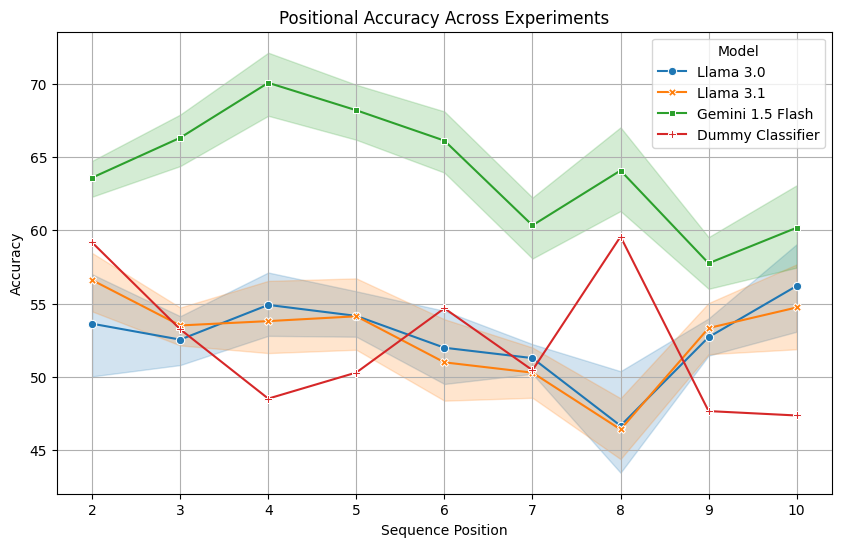

In [ ]:
# Plot a line graph for positional accuracy

# Convert df to a long format for plotting
df_long = pd.melt(df_pos_acc, id_vars=['Model'], var_name='Experiment', value_name='Accuracy')

plt.figure(figsize=(10, 6))

# Create a line plot
sns.lineplot(data=df_long, x='Experiment', y='Accuracy', hue='Model', style='Model', markers=True, dashes=False)

# Add labels etc
plt.title('Positional Accuracy Across Experiments')
plt.xlabel('Sequence Position')
plt.ylabel('Accuracy')
plt.grid(True)

# Display the plot
plt.show()

In [ ]:
# How many sessions were in this run

exp1_zeroshot_results = pd.read_csv('/content/drive/My Drive/ProjectResults2/llama3_0/Seed_1/exp1_zero_shot/exp1_zero_shot_results.csv')
print(len(exp1_zeroshot_results['session_id'].unique()))

169


In [ ]:
# How many True and False predictions do the Llama models make
# Llama 3.0
llama3_0_exp3_0shot = pd.read_csv('/content/drive/My Drive/ProjectResults2/llama3_0/Seed_1/exp3_zero_shot/exp3_zero_shot_results.csv')
llama3_0_exp3_1shot = pd.read_csv('/content/drive/My Drive/ProjectResults2/llama3_0/Seed_1/exp3_one_shot/exp3_one_shot_results.csv')

llama3_0_0shot_counts = llama3_0_exp3_0shot['skip_prediction'].value_counts()
llama3_0_1shot_counts = llama3_0_exp3_1shot['skip_prediction'].value_counts()

print(llama3_0_0shot_counts)
print(llama3_0_1shot_counts)

skip_prediction
False    1060
True      120
Name: count, dtype: int64
skip_prediction
False    694
True     486
Name: count, dtype: int64


In [ ]:
# Llama 3.1
llama3_1_exp3_0shot = pd.read_csv('/content/drive/My Drive/ProjectResults2/llama3_1/Seed_1/exp3_zero_shot/exp3_zero_shot_results.csv')
llama3_1_exp3_1shot = pd.read_csv('/content/drive/My Drive/ProjectResults2/llama3_1/Seed_1/exp3_one_shot/exp3_one_shot_results.csv')

llama3_1_0shot_counts = llama3_1_exp3_0shot['skip_prediction'].value_counts()
llama3_1_1shot_counts = llama3_1_exp3_1shot['skip_prediction'].value_counts()

print(llama3_1_0shot_counts)
print(llama3_1_1shot_counts)

skip_prediction
False      1003
True        175
Invalid       2
Name: count, dtype: int64
skip_prediction
False    769
True     411
Name: count, dtype: int64


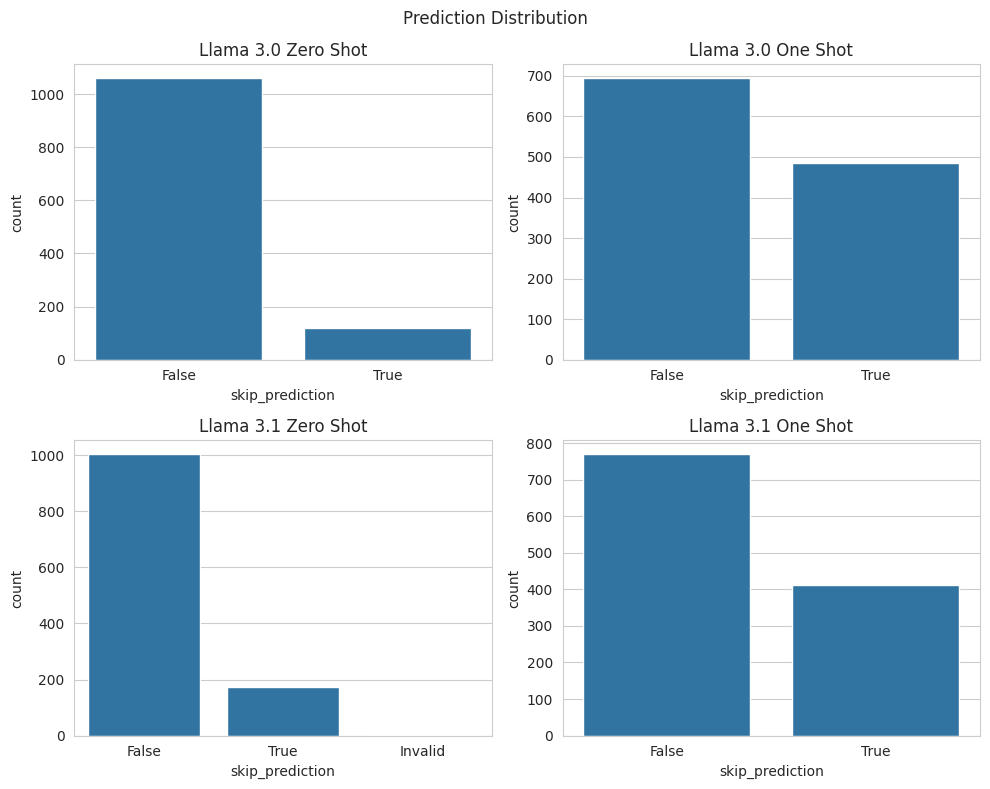

In [ ]:
# Plot the value counts as bar charts for Llama models
sns.set_style("whitegrid")

value_counts = [llama3_0_0shot_counts, llama3_0_1shot_counts, llama3_1_0shot_counts, llama3_1_1shot_counts]
labels = ['Llama 3.0 Zero Shot', 'Llama 3.0 One Shot', 'Llama 3.1 Zero Shot', 'Llama 3.1 One Shot']

# Create subplots to show a grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
fig.suptitle("Prediction Distribution")

for i, counts in enumerate(value_counts):
  ax=axes.flatten()[i]
  ax.title.set_text(labels[i])
  sns.barplot(counts, ax=ax)

plt.tight_layout()
plt.show()

